# Stage 2: XGBoost Risk Scoring Model

**LoanGuard** boru hattının ikinci aşaması — kredi temerrüt riskini tahmin eden XGBoost sınıflandırıcısı.

### Notebook Akışı
1. Kütüphaneler & Konfigürasyon
2. Veri Yükleme & Doğrulama
3. Yardımcı Fonksiyonlar (Değerlendirme & Görselleştirme)
4. Temel Model Eğitimi (Erken Durdurma ile)
5. Hiperparametre Optimizasyonu (RandomizedSearchCV)
6. Son Model Eğitimi & Eşik Optimizasyonu
7. SHAP Açıklanabilirliği
8. Model & Metrik Kayıt

**Veri:** 255.347 kredi başvurusu | **Dengesizlik:** 7.6:1 | **Özellik sayısı:** 16

## 1. Kütüphaneler & Konfigürasyon

In [1]:
import os
import json
import time
import warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib
import yaml

from scipy.stats import uniform, randint

from sklearn.model_selection import (
    StratifiedKFold,
    RandomizedSearchCV,
    train_test_split,
)
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    matthews_corrcoef,
)
from xgboost import XGBClassifier

# Uyarıları bastır — temiz çıktı için
warnings.filterwarnings("ignore")

# Tekrarlanabilirlik için global tohum
SEED = 42
np.random.seed(SEED)

# Görsel stil ayarları
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("husl")
FIGSIZE = (10, 6)

print("Tüm kütüphaneler başarıyla yüklendi.")
print(f"XGBoost sürümü : {__import__('xgboost').__version__}")
print(f"SHAP sürümü    : {shap.__version__}")

Tüm kütüphaneler başarıyla yüklendi.
XGBoost sürümü : 2.1.3
SHAP sürümü    : 0.46.0


In [2]:
# Notebook, LoanGuard/notebooks/ dizininde çalışır; proje kökü bir üst dizindir
PROJECT_ROOT = Path("..").resolve()
CONFIG_PATH  = PROJECT_ROOT / "configs" / "model_params.yaml"

# YAML konfigürasyon dosyasını oku
with open(CONFIG_PATH, "r") as f:
    config = yaml.safe_load(f)

# Aşama 2 (risk skorlama) parametrelerini çıkar
xgb_cfg    = config["risk_scoring"]["params"]
data_cfg   = config["data"]
preproc_cfg = config["preprocessing"]
thresh_cfg  = config.get("threshold_optimization", {})
MIN_RECALL  = thresh_cfg.get("min_recall", 0.70)

# Dizin yollarını tanımla
DATA_DIR    = PROJECT_ROOT / "data" / "processed"
MODELS_DIR  = PROJECT_ROOT / "models"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
METRICS_DIR = PROJECT_ROOT / "reports" / "metrics"

# Çıktı dizinlerini oluştur (yoksa)
for d in [MODELS_DIR, FIGURES_DIR, METRICS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f"Proje kökü : {PROJECT_ROOT}")
print(f"Min Recall hedefi : {MIN_RECALL}")
print(f"\nXGBoost başlangıç parametreleri:")
for k, v in xgb_cfg.items():
    print(f"  {k:<25}: {v}")

Proje kökü : C:\Users\nesli\Desktop\LoanGuard
Min Recall hedefi : 0.7

XGBoost başlangıç parametreleri:
  n_estimators             : 300
  max_depth                : 6
  learning_rate            : 0.1
  subsample                : 0.8
  colsample_bytree         : 0.8
  scale_pos_weight         : 7.6
  random_state             : 42
  eval_metric              : auc
  use_label_encoder        : False


## 2. Veri Yükleme & Doğrulama

In [3]:
def load_processed_data(data_dir: Path) -> tuple:
    """
    02_preprocessing.ipynb tarafından oluşturulan işlenmiş veri setlerini yükler.
    Döndürür: (X_train, X_test, y_train, y_test)
    """
    X_train = pd.read_csv(data_dir / "X_train.csv")
    X_test  = pd.read_csv(data_dir / "X_test.csv")
    # squeeze(): tek sütunlu DataFrame'i Series'e çevir
    y_train = pd.read_csv(data_dir / "y_train.csv").squeeze()
    y_test  = pd.read_csv(data_dir / "y_test.csv").squeeze()
    return X_train, X_test, y_train, y_test


X_train, X_test, y_train, y_test = load_processed_data(DATA_DIR)

# Boyut ve dağılım doğrulaması
print(f"{'Eğitim seti':<20}: {X_train.shape}")
print(f"{'Test seti':<20}: {X_test.shape}")
print(f"{'Özellik isimleri':<20}: {list(X_train.columns)}")
print()
for split_name, y_split in [("Eğitim", y_train), ("Test", y_test)]:
    counts = y_split.value_counts()
    ratio  = counts[0] / counts[1]
    print(f"{split_name} — Ödendi: {counts[0]:,}  |  Temerrüt: {counts[1]:,}  |  Oran: {ratio:.2f}:1")

Eğitim seti         : (204277, 20)
Test seti           : (51070, 20)
Özellik isimleri    : ['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner', 'LoanToIncome', 'PaymentToIncome', 'CreditAgePerLine', 'TotalDebtBurden']

Eğitim — Ödendi: 180,555  |  Temerrüt: 23,722  |  Oran: 7.61:1
Test — Ödendi: 45,139  |  Temerrüt: 5,931  |  Oran: 7.61:1


In [4]:
def validate_data(X: pd.DataFrame, y: pd.Series, name: str) -> None:
    """Eksik değer, inf ve tip tutarsızlıklarını kontrol eder."""
    assert X.isnull().sum().sum() == 0,  f"{name}: X'te eksik değer var!"
    assert y.isnull().sum()       == 0,  f"{name}: y'de eksik değer var!"
    assert not np.isinf(X.values).any(), f"{name}: X'te sonsuz değer var!"
    assert set(y.unique()) == {0, 1},    f"{name}: Hedef sütunda beklenmedik değer var!"
    print(f"[OK] {name} doğrulandı — {X.shape[0]:,} örnek, {X.shape[1]} özellik")


validate_data(X_train, y_train, "Eğitim seti")
validate_data(X_test,  y_test,  "Test seti")

[OK] Eğitim seti doğrulandı — 204,277 örnek, 20 özellik
[OK] Test seti doğrulandı — 51,070 örnek, 20 özellik


## 3. Yardımcı Fonksiyonlar

In [5]:
# --- Değerlendirme Fonksiyonları ---

def evaluate_model(
    y_true: pd.Series,
    y_pred: np.ndarray,
    y_prob: np.ndarray,
    threshold: float = 0.5,
    label: str = "Model",
) -> dict:
    """
    Modelin tüm performans metriklerini hesaplar ve tablo formatında raporlar.

    Args:
        y_true    : Gerçek etiketler
        y_pred    : İkili tahminler (0/1)
        y_prob    : Pozitif sınıf olasılıkları
        threshold : Karar eşiği
        label     : Rapor başlığı

    Returns:
        Metrik adı → değer sözlüğü
    """
    metrics = {
        "roc_auc"       : roc_auc_score(y_true, y_prob),
        "pr_auc"        : average_precision_score(y_true, y_prob),
        "f1"            : f1_score(y_true, y_pred),
        "precision"     : precision_score(y_true, y_pred),
        "recall"        : recall_score(y_true, y_pred),
        # MCC: sınıf dengesizliğinde F1'den daha güvenilir metrik
        "mcc"           : matthews_corrcoef(y_true, y_pred),
        "threshold"     : threshold,
    }

    print(f"\n{'='*55}")
    print(f"  {label.upper()}  (Eşik = {threshold:.4f})")
    print(f"{'='*55}")
    print(f"  {'ROC-AUC':<30} {metrics['roc_auc']:>8.4f}")
    print(f"  {'PR-AUC':<30} {metrics['pr_auc']:>8.4f}")
    print(f"  {'F1 Skoru':<30} {metrics['f1']:>8.4f}")
    print(f"  {'Hassasiyet (Precision)':<30} {metrics['precision']:>8.4f}")
    print(f"  {'Duyarlılık (Recall)':<30} {metrics['recall']:>8.4f}")
    print(f"  {'MCC':<30} {metrics['mcc']:>8.4f}")
    print(f"{'='*55}")
    print(classification_report(y_true, y_pred, target_names=["Ödendi", "Temerrüt"]))

    return metrics


def find_optimal_threshold(
    y_true: pd.Series,
    y_prob: np.ndarray,
    min_recall: float = MIN_RECALL,
) -> float:
    """
    Recall >= min_recall koşulunu sağlayan eşikler arasından
    Precision'ı maksimize eden karar eşiğini bulur.

    Args:
        min_recall : Hedef minimum Recall (bankacılık riski için varsayılan 0.70)
    Returns:
        Optimal eşik değeri (float)
    """
    precision_arr, recall_arr, thresholds = precision_recall_curve(y_true, y_prob)

    # [:-1]: precision_recall_curve son noktası eşiksizdir (recall=1, precision=prior)
    valid_mask = recall_arr[:-1] >= min_recall

    if valid_mask.any():
        valid_precisions = precision_arr[:-1][valid_mask]
        valid_thresholds = thresholds[valid_mask]
        best_idx       = int(np.argmax(valid_precisions))
        best_threshold = float(valid_thresholds[best_idx])
        best_precision = float(valid_precisions[best_idx])
        best_recall    = float(recall_arr[:-1][valid_mask][best_idx])
    else:
        # Fallback: min_recall sağlanamıyorsa en yüksek recall'daki max precision
        print(f"[UYARI] Recall >= {min_recall:.2f} sağlayan eşik bulunamadı. Fallback uygulandı.")
        best_idx       = int(np.argmax(recall_arr[:-1]))
        best_threshold = float(thresholds[best_idx])
        best_precision = float(precision_arr[best_idx])
        best_recall    = float(recall_arr[best_idx])

    print(f"Optimal eşik       : {best_threshold:.4f}")
    print(f"Bu eşikteki Recall : {best_recall:.4f}")
    print(f"Bu eşikteki Precis.: {best_precision:.4f}")

    return best_threshold

In [6]:
# --- Görselleştirme Fonksiyonları ---

def plot_roc_curve(
    y_true: pd.Series,
    models: dict,
    save_path: Path = None,
) -> None:
    """
    Bir veya birden fazla model için ROC eğrisini tek grafik üzerinde çizer.

    Args:
        y_true    : Gerçek etiketler
        models    : {model_adı: olasılık_dizisi} sözlüğü
        save_path : Kaydedilecek dosya yolu
    """
    fig, ax = plt.subplots(figsize=FIGSIZE)

    for name, y_prob in models.items():
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        auc = roc_auc_score(y_true, y_prob)
        ax.plot(fpr, tpr, linewidth=2.5, label=f"{name}  (AUC = {auc:.4f})")

    # Rastgele sınıflandırıcı referansı
    ax.plot([0, 1], [0, 1], "k--", linewidth=1, alpha=0.6, label="Rastgele")

    ax.set_xlabel("Yanlış Pozitif Oranı (FPR)", fontsize=12)
    ax.set_ylabel("Doğru Pozitif Oranı (TPR)", fontsize=12)
    ax.set_title("ROC Eğrisi — XGBoost Risk Modeli", fontsize=14, fontweight="bold")
    ax.legend(loc="lower right", fontsize=11)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.02])

    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Kaydedildi: {save_path.name}")
    plt.show()


def plot_pr_curve(
    y_true: pd.Series,
    models: dict,
    save_path: Path = None,
) -> None:
    """
    Precision-Recall eğrisi çizer.
    Sınıf dengesizliğinde ROC'dan daha bilgilendiricidir.

    Args:
        y_true    : Gerçek etiketler
        models    : {model_adı: olasılık_dizisi} sözlüğü
        save_path : Kaydedilecek dosya yolu
    """
    fig, ax = plt.subplots(figsize=FIGSIZE)

    # Temel oran çizgisi (becerisi olmayan sınıflandırıcı referansı)
    baseline = y_true.mean()
    ax.axhline(
        y=baseline, color="k", linestyle="--", linewidth=1,
        alpha=0.6, label=f"Temel Oran ({baseline:.3f})"
    )

    for name, y_prob in models.items():
        prec, rec, _ = precision_recall_curve(y_true, y_prob)
        ap = average_precision_score(y_true, y_prob)
        ax.plot(rec, prec, linewidth=2.5, label=f"{name}  (AP = {ap:.4f})")

    ax.set_xlabel("Duyarlılık (Recall)", fontsize=12)
    ax.set_ylabel("Hassasiyet (Precision)", fontsize=12)
    ax.set_title("Precision-Recall Eğrisi — XGBoost Risk Modeli", fontsize=14, fontweight="bold")
    ax.legend(loc="upper right", fontsize=11)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.02])

    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Kaydedildi: {save_path.name}")
    plt.show()


def plot_confusion_matrix(
    y_true: pd.Series,
    y_pred: np.ndarray,
    title: str = "Karmaşıklık Matrisi",
    save_path: Path = None,
) -> None:
    """
    Ham sayılar ve normalize edilmiş karmaşıklık matrislerini yan yana çizer.

    Args:
        y_true    : Gerçek etiketler
        y_pred    : Tahmin edilen etiketler
        title     : Grafik ana başlığı
        save_path : Kaydedilecek dosya yolu
    """
    cm_raw  = confusion_matrix(y_true, y_pred)
    cm_norm = confusion_matrix(y_true, y_pred, normalize="true").round(3)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    ConfusionMatrixDisplay(cm_raw,  display_labels=["Ödendi", "Temerrüt"]).plot(
        ax=axes[0], colorbar=False, cmap="Blues"
    )
    axes[0].set_title("Ham Sayılar", fontsize=12)

    ConfusionMatrixDisplay(cm_norm, display_labels=["Ödendi", "Temerrüt"]).plot(
        ax=axes[1], colorbar=False, cmap="Blues"
    )
    axes[1].set_title("Normalize (Satır Bazında)", fontsize=12)

    fig.suptitle(title, fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Kaydedildi: {save_path.name}")
    plt.show()


def plot_threshold_analysis(
    y_true: pd.Series,
    y_prob: np.ndarray,
    save_path: Path = None,
    min_recall: float = MIN_RECALL,
) -> float:
    """
    Farklı karar eşiklerinde Precision, Recall ve F1 skorlarını görselleştirir.
    Optimal eşiği Recall >= min_recall koşulu altında max Precision olarak işaretler.

    Returns:
        Recall-kısıtlı optimal eşik değeri
    """
    thresholds = np.linspace(0.01, 0.99, 300)
    precisions = []
    recalls    = []
    f1_scores  = []

    for t in thresholds:
        y_pred_t = (y_prob >= t).astype(int)
        precisions.append(precision_score(y_true, y_pred_t, zero_division=0))
        recalls.append(recall_score(y_true, y_pred_t, zero_division=0))
        f1_scores.append(f1_score(y_true, y_pred_t, zero_division=0))

    precisions_arr = np.array(precisions)
    recalls_arr    = np.array(recalls)

    valid_mask = recalls_arr >= min_recall
    if valid_mask.any():
        best_idx       = int(np.argmax(precisions_arr[valid_mask]))
        best_threshold = float(thresholds[valid_mask][best_idx])
    else:
        best_threshold = float(thresholds[int(np.argmax(recalls_arr))])

    fig, ax = plt.subplots(figsize=FIGSIZE)
    ax.plot(thresholds, precisions, label="Hassasiyet (Precision)", linewidth=2)
    ax.plot(thresholds, recalls,    label="Duyarlılık (Recall)",    linewidth=2)
    ax.plot(thresholds, f1_scores,  label="F1 Skoru",               linewidth=1.5, linestyle="--", alpha=0.7)
    ax.axhline(
        y=min_recall, color="orange", linestyle=":", linewidth=1.5,
        label=f"Min Recall Hedefi ({min_recall:.2f})"
    )
    ax.axvline(
        x=best_threshold, color="red", linestyle="--", linewidth=1.8,
        label=f"Optimal Eşik ({best_threshold:.3f})"
    )

    ax.set_xlabel("Karar Eşiği", fontsize=12)
    ax.set_ylabel("Skor", fontsize=12)
    ax.set_title(
        f"Eşik Analizi — Recall >= {min_recall:.2f} Koşulunda Max Precision",
        fontsize=14, fontweight="bold"
    )
    ax.legend(fontsize=11)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])

    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Kaydedildi: {save_path.name}")
    plt.show()

    return best_threshold

## 4. Temel Model Eğitimi

In [7]:
# Erken durdurma için eğitim setinin %15'ini geçerleme seti olarak ayır
# Bu bölünme yalnızca eğitim optimizasyonu içindir; test seti dokunulmaz kalır
X_fit, X_val, y_fit, y_val = train_test_split(
    X_train, y_train,
    test_size  = 0.15,
    stratify   = y_train,   # Sınıf oranını koru
    random_state = SEED,
)

print(f"{'Eğitim (fit)  '}: {X_fit.shape[0]:>7,} örnek")
print(f"{'Geçerleme     '}: {X_val.shape[0]:>7,} örnek")
print(f"{'Test (dokunulmaz)'}: {X_test.shape[0]:>7,} örnek")

Eğitim (fit)  : 173,635 örnek
Geçerleme     :  30,642 örnek
Test (dokunulmaz):  51,070 örnek


In [8]:
# YAML konfigürasyonundan temel parametreler
baseline_params = {
    "n_estimators"        : xgb_cfg["n_estimators"],
    "max_depth"           : xgb_cfg["max_depth"],
    "learning_rate"       : xgb_cfg["learning_rate"],
    "subsample"           : xgb_cfg["subsample"],
    "colsample_bytree"    : xgb_cfg["colsample_bytree"],
    # 7.6:1 sınıf dengesizliğini telafi eder; temerrüt sınıfına daha yüksek ağırlık verir
    "scale_pos_weight"    : xgb_cfg["scale_pos_weight"],
    "eval_metric"         : "auc",
    "random_state"        : SEED,
    "n_jobs"              : -1,      # Tüm CPU çekirdeklerini kullan
    "tree_method"         : "hist",  # Büyük veri setleri için hızlı histogram yöntemi
    "early_stopping_rounds": 30,     # 30 tur iyileşme yoksa eğitimi durdur
}

baseline_model = XGBClassifier(**baseline_params)

print("Temel model eğitiliyor...")
t0 = time.time()

baseline_model.fit(
    X_fit, y_fit,
    eval_set = [(X_val, y_val)],  # Erken durdurma için geçerleme seti
    verbose  = 50,                # Her 50 iterasyonda ilerlemeyi göster
)

print(f"\nEğitim süresi   : {time.time() - t0:.1f} saniye")
print(f"En iyi iterasyon: {baseline_model.best_iteration}")
print(f"En iyi AUC      : {baseline_model.best_score:.4f}  (geçerleme seti)")

Temel model eğitiliyor...
[0]	validation_0-auc:0.70105
[50]	validation_0-auc:0.74370
[82]	validation_0-auc:0.74324

Eğitim süresi   : 1.2 saniye
En iyi iterasyon: 53
En iyi AUC      : 0.7439  (geçerleme seti)



  TEMEL XGBOOST (TEST SETI)  (Eşik = 0.5000)
  ROC-AUC                          0.7549
  PR-AUC                           0.3278
  F1 Skoru                         0.3427
  Hassasiyet (Precision)           0.2299
  Duyarlılık (Recall)              0.6727
  MCC                              0.2548
              precision    recall  f1-score   support

      Ödendi       0.94      0.70      0.81     45139
    Temerrüt       0.23      0.67      0.34      5931

    accuracy                           0.70     51070
   macro avg       0.59      0.69      0.57     51070
weighted avg       0.86      0.70      0.75     51070

Kaydedildi: xgb_01_roc_baseline.png


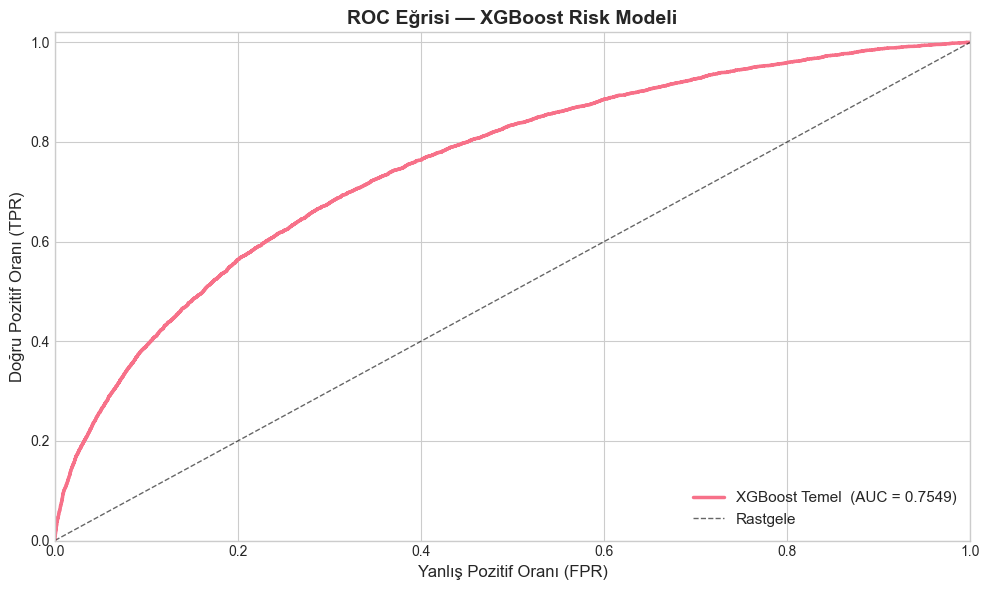

Kaydedildi: xgb_02_pr_baseline.png


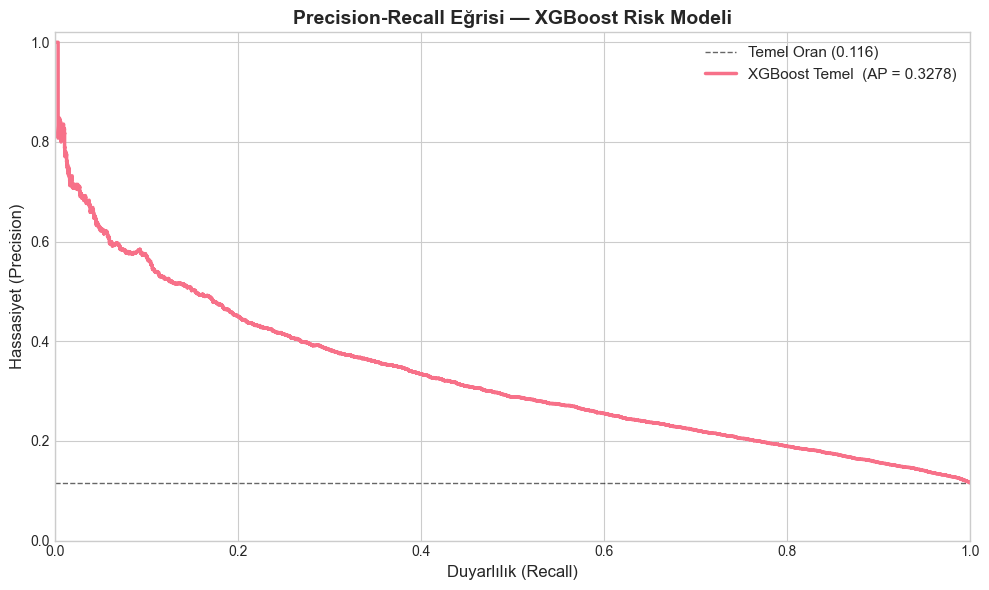

Kaydedildi: xgb_03_cm_baseline.png


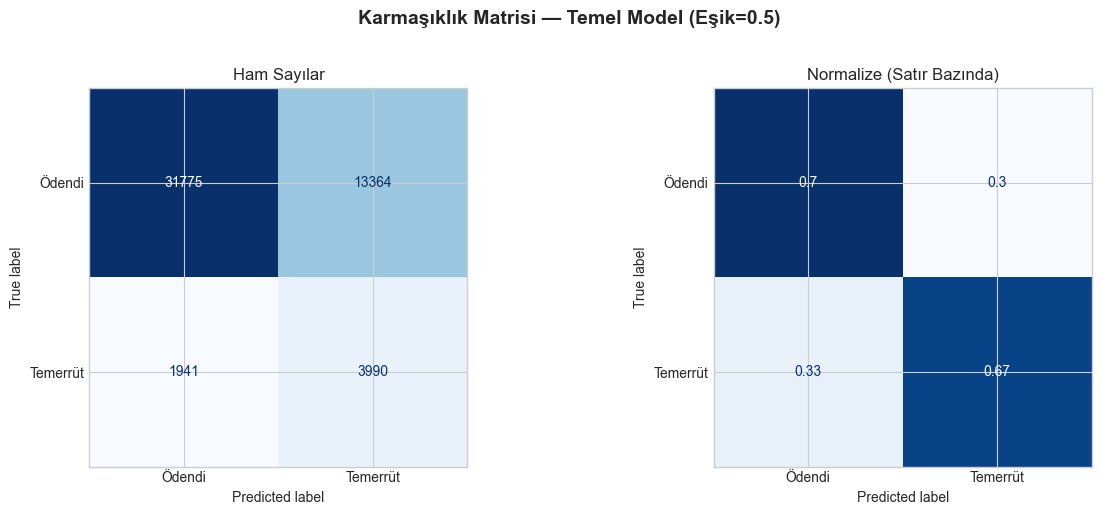

In [9]:
# Test seti üzerinde temel model değerlendirmesi
y_prob_baseline = baseline_model.predict_proba(X_test)[:, 1]  # Pozitif sınıf (temerrüt) olasılıkları
y_pred_baseline = (y_prob_baseline >= 0.5).astype(int)

baseline_metrics = evaluate_model(
    y_test, y_pred_baseline, y_prob_baseline,
    threshold=0.5, label="Temel XGBoost (Test Seti)"
)

# Temel model görselleştirmeleri
plot_roc_curve(
    y_test,
    {"XGBoost Temel": y_prob_baseline},
    save_path=FIGURES_DIR / "xgb_01_roc_baseline.png",
)
plot_pr_curve(
    y_test,
    {"XGBoost Temel": y_prob_baseline},
    save_path=FIGURES_DIR / "xgb_02_pr_baseline.png",
)
plot_confusion_matrix(
    y_test, y_pred_baseline,
    title="Karmaşıklık Matrisi — Temel Model (Eşik=0.5)",
    save_path=FIGURES_DIR / "xgb_03_cm_baseline.png",
)

## 5. Hiperparametre Optimizasyonu

`RandomizedSearchCV` ile geniş parametre uzayında arama yapılır.  
**Not:** Bu adım `n_iter=20`, `cv=3` ile yaklaşık 5–15 dakika sürebilir.

In [10]:
# Arama uzayı: her parametre için olası değer dağılımları
param_distributions = {
    "n_estimators"     : [200, 300, 400, 500],     # Ağaç sayısı
    "max_depth"        : randint(3, 10),            # Ağaç derinliği
    "learning_rate"    : uniform(0.03, 0.17),       # Öğrenme oranı
    "subsample"        : uniform(0.65, 0.30),       # Satır alt-örnekleme oranı
    "colsample_bytree" : uniform(0.55, 0.40),       # Sütun alt-örnekleme oranı
    "min_child_weight" : randint(1, 12),            # Yaprak düğüm minimum örnek sayısı
    "gamma"            : uniform(0.0, 0.5),         # Bölme için minimum kayıp azalması
    "reg_alpha"        : uniform(0.0, 1.0),         # L1 düzenleştirme (seyreklik)
    "reg_lambda"       : uniform(0.5, 2.0),         # L2 düzenleştirme (büyüklük cezası)
}

# Arama için temel model — early_stopping_rounds RandomizedSearchCV ile uyumsuz
search_estimator = XGBClassifier(
    scale_pos_weight = xgb_cfg["scale_pos_weight"],
    eval_metric      = "auc",
    tree_method      = "hist",
    random_state     = SEED,
    n_jobs           = 1,   # CV'nin kendi paralelliği ile çakışmayı önler
)

# Stratified K-Fold: her katte sınıf oranı korunur
cv_strategy = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

random_search = RandomizedSearchCV(
    estimator           = search_estimator,
    param_distributions = param_distributions,
    n_iter              = 20,          # 20 rastgele kombinasyon dene
    scoring             = "roc_auc",  # Optimize edilecek hedef metrik
    cv                  = cv_strategy,
    n_jobs              = -1,          # Tüm çekirdekleri kullan
    random_state        = SEED,
    verbose             = 2,
    refit               = True,        # En iyi params ile tam veri üzerinde yeniden eğit
    return_train_score  = False,
)

print("Hiperparametre araması başlıyor...")
print(f"Toplam deneme: {20} iterasyon × {3} kat = 60 model eğitimi")
t0 = time.time()

random_search.fit(X_train, y_train)  # Tam eğitim setinde ara

elapsed = time.time() - t0
print(f"\nArama tamamlandı: {elapsed/60:.1f} dakika")
print(f"En iyi CV AUC   : {random_search.best_score_:.4f}")
print("\nEn iyi parametreler:")
for k, v in sorted(random_search.best_params_.items()):
    print(f"  {k:<25}: {v}")

Hiperparametre araması başlıyor...
Toplam deneme: 20 iterasyon × 3 kat = 60 model eğitimi
Fitting 3 folds for each of 20 candidates, totalling 60 fits

Arama tamamlandı: 1.5 dakika
En iyi CV AUC   : 0.7528

En iyi parametreler:
  colsample_bytree         : 0.9406459823330613
  gamma                    : 0.20551850665911564
  learning_rate            : 0.03561862459309322
  max_depth                : 3
  min_child_weight         : 1
  n_estimators             : 400
  reg_alpha                : 0.6807054515547668
  reg_lambda               : 1.5618691666342728
  subsample                : 0.7843349493719275


## 6. Son Model — Eğitim, Değerlendirme & Eşik Optimizasyonu

In [11]:
# En iyi parametrelerle son modeli eğit; bu sefer erken durdurma aktif
final_params = {
    **random_search.best_params_,
    "scale_pos_weight"    : xgb_cfg["scale_pos_weight"],
    "eval_metric"         : "auc",
    "tree_method"         : "hist",
    "random_state"        : SEED,
    "n_jobs"              : -1,
    "early_stopping_rounds": 30,
}

final_model = XGBClassifier(**final_params)

print("Son model eğitiliyor (en iyi parametreler + erken durdurma)...")
t0 = time.time()

final_model.fit(
    X_fit, y_fit,
    eval_set = [(X_val, y_val)],
    verbose  = 50,
)

print(f"\nEğitim süresi   : {time.time() - t0:.1f} saniye")
print(f"En iyi iterasyon: {final_model.best_iteration}")
print(f"En iyi val AUC  : {final_model.best_score:.4f}")

Son model eğitiliyor (en iyi parametreler + erken durdurma)...
[0]	validation_0-auc:0.68071
[50]	validation_0-auc:0.73006
[100]	validation_0-auc:0.73763
[150]	validation_0-auc:0.74209
[200]	validation_0-auc:0.74481
[250]	validation_0-auc:0.74628
[300]	validation_0-auc:0.74716
[350]	validation_0-auc:0.74760
[399]	validation_0-auc:0.74774

Eğitim süresi   : 3.7 saniye
En iyi iterasyon: 397
En iyi val AUC  : 0.7477


OPTIMAL EŞİK ANALİZİ
----------------------------------------
Optimal eşik       : 0.4914
Bu eşikteki Recall : 0.7007
Bu eşikteki Precis.: 0.2246
Kaydedildi: xgb_04_threshold_analysis.png


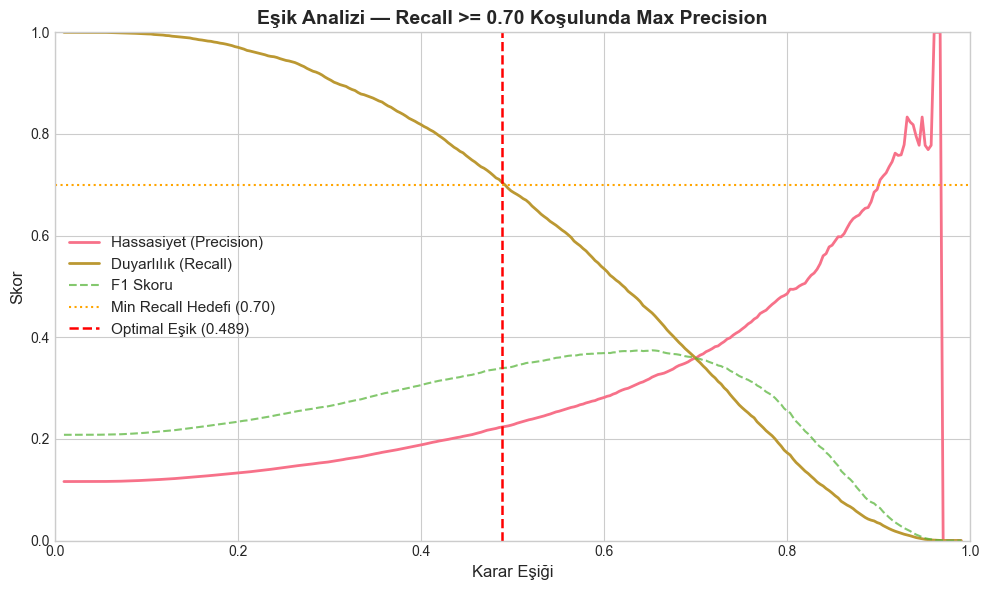

In [12]:
# Test seti üzerinde olasılık tahminleri
y_prob_final = final_model.predict_proba(X_test)[:, 1]

# Optimal karar eşiğini bul
print("OPTIMAL EŞİK ANALİZİ")
print("-" * 40)
optimal_threshold = find_optimal_threshold(y_test, y_prob_final)

# Eşik analizi grafiği
optimal_threshold = plot_threshold_analysis(
    y_test, y_prob_final,
    save_path=FIGURES_DIR / "xgb_04_threshold_analysis.png",
)

In [13]:
# İki eşikle tam değerlendirme
y_pred_05  = (y_prob_final >= 0.500).astype(int)
y_pred_opt = (y_prob_final >= optimal_threshold).astype(int)

metrics_05  = evaluate_model(
    y_test, y_pred_05, y_prob_final,
    threshold=0.5, label="Son Model — Eşik=0.5"
)
metrics_opt = evaluate_model(
    y_test, y_pred_opt, y_prob_final,
    threshold=optimal_threshold,
    label=f"Son Model — Optimal Eşik={optimal_threshold:.4f}"
)


  SON MODEL — EŞIK=0.5  (Eşik = 0.5000)
  ROC-AUC                          0.7595
  PR-AUC                           0.3336
  F1 Skoru                         0.3419
  Hassasiyet (Precision)           0.2277
  Duyarlılık (Recall)              0.6859
  MCC                              0.2554
              precision    recall  f1-score   support

      Ödendi       0.94      0.69      0.80     45139
    Temerrüt       0.23      0.69      0.34      5931

    accuracy                           0.69     51070
   macro avg       0.59      0.69      0.57     51070
weighted avg       0.86      0.69      0.75     51070


  SON MODEL — OPTIMAL EŞIK=0.4885  (Eşik = 0.4885)
  ROC-AUC                          0.7595
  PR-AUC                           0.3336
  F1 Skoru                         0.3393
  Hassasiyet (Precision)           0.2234
  Duyarlılık (Recall)              0.7048
  MCC                              0.2547
              precision    recall  f1-score   support

      Ödendi       0.

Kaydedildi: xgb_05_roc_comparison.png


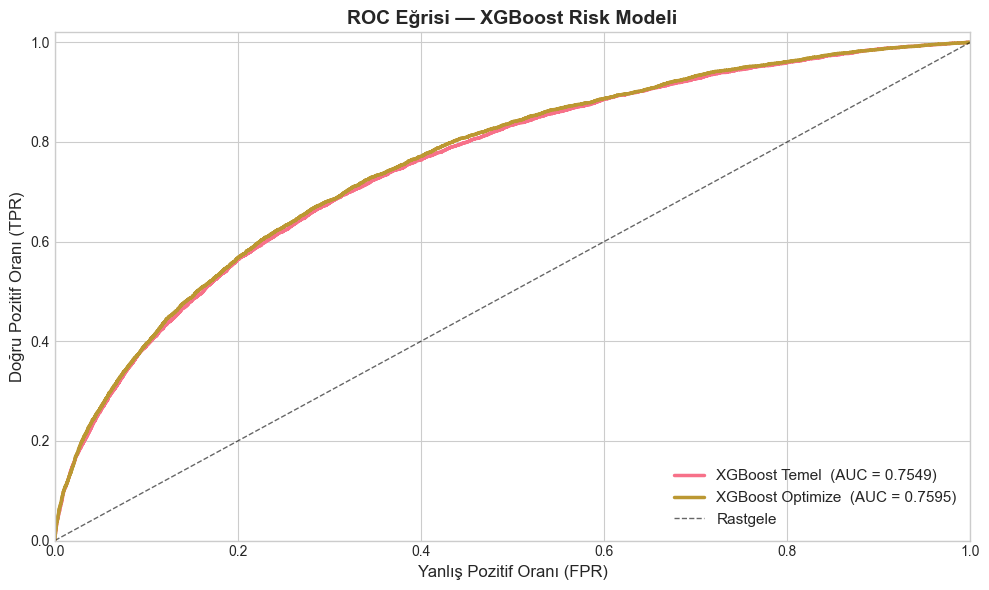

Kaydedildi: xgb_06_pr_comparison.png


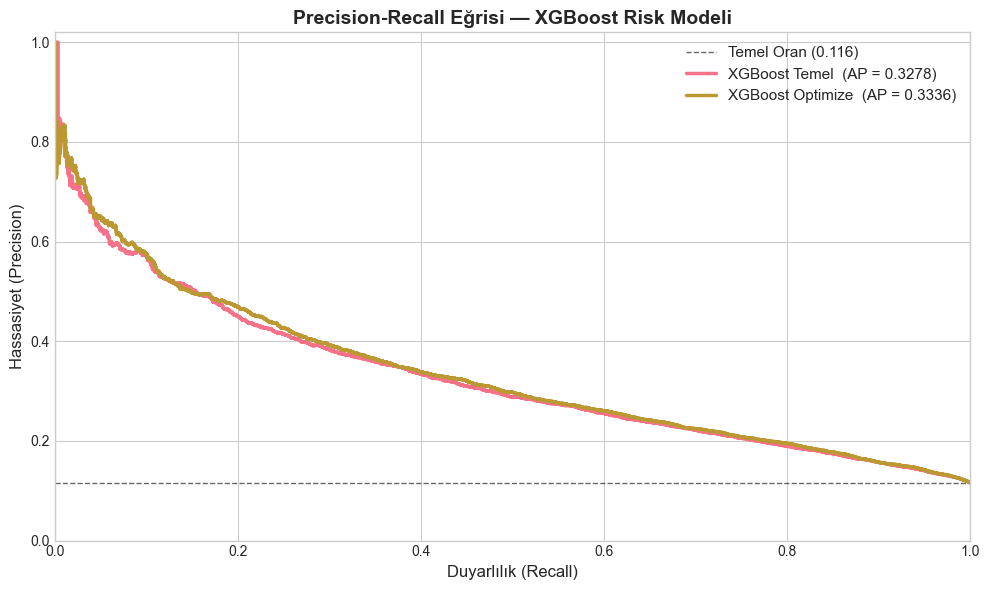

Kaydedildi: xgb_07_cm_05.png


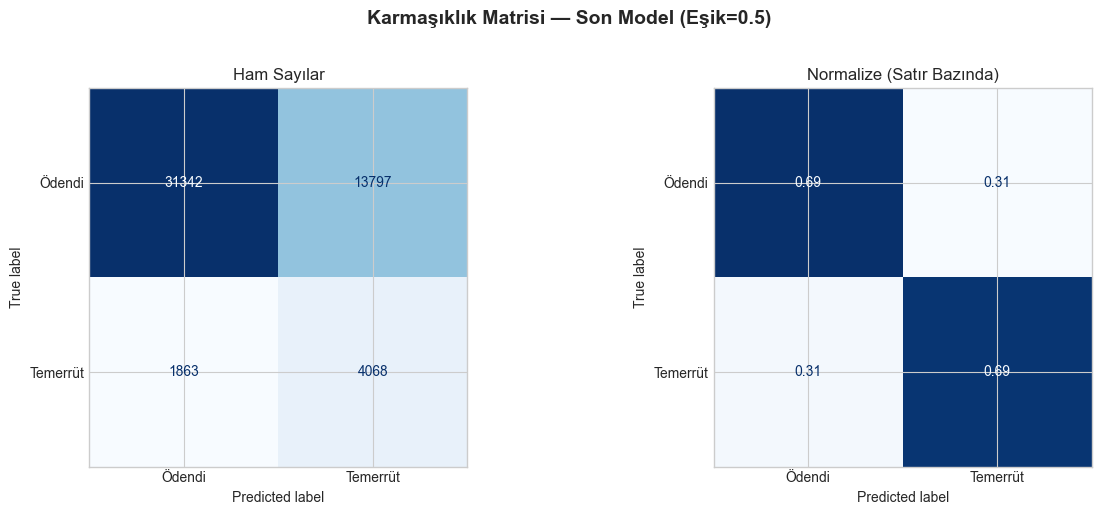

Kaydedildi: xgb_08_cm_optimal.png


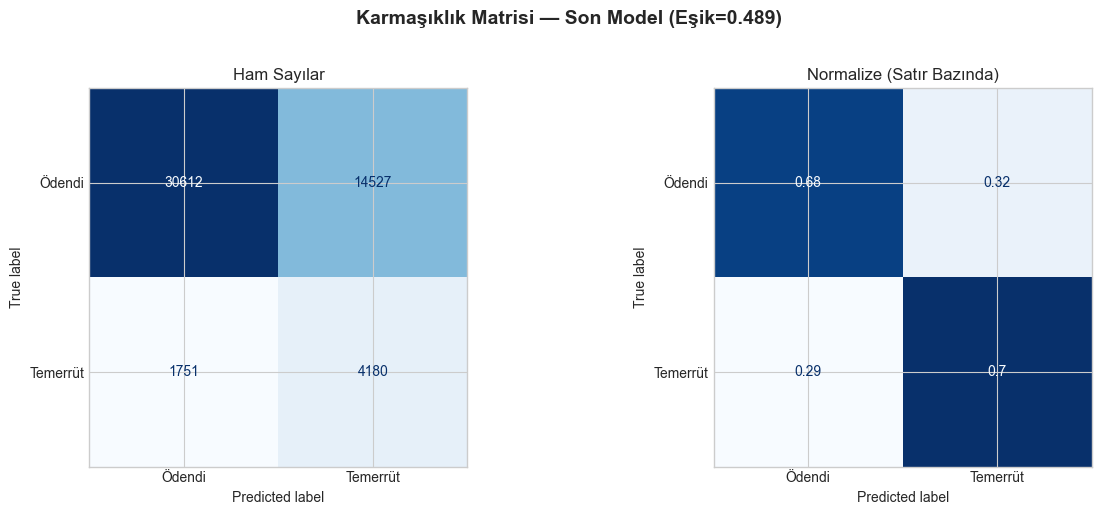

In [14]:
# Temel model vs. son model ROC ve PR karşılaştırması
model_probs = {
    "XGBoost Temel"   : y_prob_baseline,
    "XGBoost Optimize": y_prob_final,
}

plot_roc_curve(y_test, model_probs,
               save_path=FIGURES_DIR / "xgb_05_roc_comparison.png")
plot_pr_curve(y_test, model_probs,
              save_path=FIGURES_DIR / "xgb_06_pr_comparison.png")

# Karmaşıklık matrisleri: her iki eşik için
plot_confusion_matrix(
    y_test, y_pred_05,
    title="Karmaşıklık Matrisi — Son Model (Eşik=0.5)",
    save_path=FIGURES_DIR / "xgb_07_cm_05.png",
)
plot_confusion_matrix(
    y_test, y_pred_opt,
    title=f"Karmaşıklık Matrisi — Son Model (Eşik={optimal_threshold:.3f})",
    save_path=FIGURES_DIR / "xgb_08_cm_optimal.png",
)

## 7. Özellik Önemi & SHAP Açıklanabilirliği

Kaydedildi: xgb_09_feature_importance.png


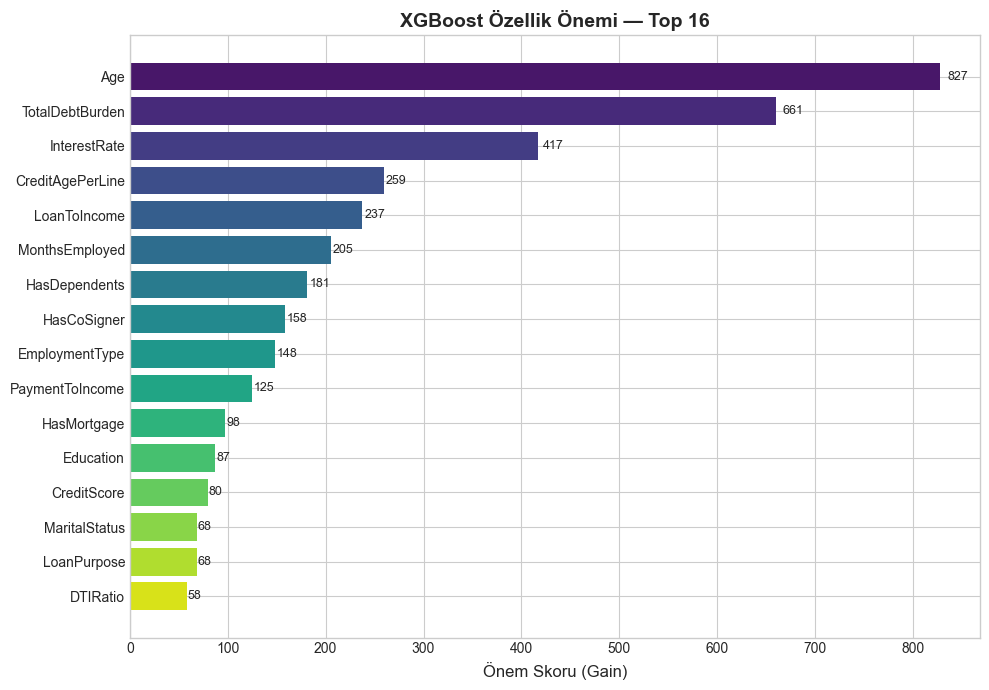


En önemli 10 özellik (Gain):
         feature      score
             Age 827.388794
 TotalDebtBurden 660.571167
    InterestRate 417.338104
CreditAgePerLine 259.106567
    LoanToIncome 236.965851
  MonthsEmployed 205.332626
   HasDependents 181.396561
     HasCoSigner 158.466476
  EmploymentType 148.199234
 PaymentToIncome 124.958069


In [15]:
def plot_feature_importance(
    model: XGBClassifier,
    feature_names: list,
    importance_type: str = "gain",
    top_n: int = 16,
    save_path: Path = None,
) -> pd.DataFrame:
    """
    XGBoost'un dahili özellik önem skorlarını yatay çubuk grafik ile gösterir.

    Args:
        importance_type : "gain" (ortalama kazanç), "weight" (bölme sayısı) veya "cover"
        top_n           : Gösterilecek en önemli özellik sayısı

    Returns:
        Özellik önem DataFrame'i (sıralı)
    """
    # Booster nesnesinden ham önem skorlarını al
    raw_importance = final_model.get_booster().get_score(importance_type=importance_type)

    importance_df = (
        pd.DataFrame.from_dict(raw_importance, orient="index", columns=["score"])
        .reset_index()
        .rename(columns={"index": "feature"})
        .sort_values("score", ascending=False)
        .head(top_n)
        .reset_index(drop=True)
    )

    palette = sns.color_palette("viridis", len(importance_df))

    fig, ax = plt.subplots(figsize=(10, 7))
    bars = ax.barh(
        importance_df["feature"][::-1],
        importance_df["score"][::-1],
        color=palette[::-1],
    )

    # Değerleri çubuk uçlarına yaz
    for bar in bars:
        w = bar.get_width()
        ax.text(
            w * 1.01, bar.get_y() + bar.get_height() / 2,
            f"{w:,.0f}", va="center", fontsize=9,
        )

    ax.set_xlabel(f"Önem Skoru ({importance_type.capitalize()})", fontsize=12)
    ax.set_title(f"XGBoost Özellik Önemi — Top {top_n}", fontsize=14, fontweight="bold")
    plt.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Kaydedildi: {save_path.name}")
    plt.show()

    return importance_df


importance_df = plot_feature_importance(
    final_model,
    feature_names=list(X_train.columns),
    importance_type="gain",
    save_path=FIGURES_DIR / "xgb_09_feature_importance.png",
)
print("\nEn önemli 10 özellik (Gain):")
print(importance_df.head(10).to_string(index=False))

In [16]:
# SHAP değerleri hesaplanır — TreeExplainer XGBoost için optimize edilmiş hızlı yöntemdir
# Büyük test seti için bellek tasarrufu amacıyla örnekleme yapılır
SHAP_SAMPLE_SIZE = 5_000

# X_shap ve y_shap'ın aynı satırlara karşılık geldiğinden emin olmak için indeksler eşleştirilir
shap_idx = X_test.sample(n=SHAP_SAMPLE_SIZE, random_state=SEED).index
X_shap   = X_test.loc[shap_idx].reset_index(drop=True)
y_shap   = y_test.loc[shap_idx].reset_index(drop=True)

print("SHAP TreeExplainer oluşturuluyor...")
explainer = shap.TreeExplainer(final_model)

print(f"SHAP değerleri hesaplanıyor ({SHAP_SAMPLE_SIZE} örnek)...")
t0 = time.time()
shap_values = explainer.shap_values(X_shap)
print(f"Tamamlandı: {time.time() - t0:.1f} saniye")
print(f"SHAP matrisi boyutu: {shap_values.shape}  → (örnek, özellik)")

SHAP TreeExplainer oluşturuluyor...
SHAP değerleri hesaplanıyor (5000 örnek)...
Tamamlandı: 0.2 saniye
SHAP matrisi boyutu: (5000, 20)  → (örnek, özellik)


Kaydedildi: xgb_10_shap_beeswarm.png


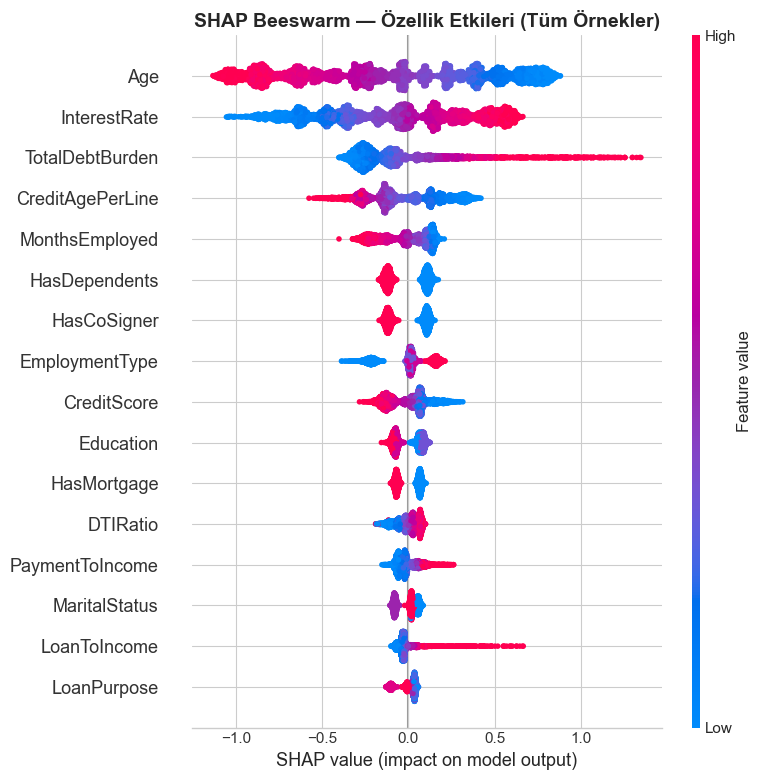

In [17]:
# SHAP Beeswarm — her örnek için her özelliğin katkısını gösterir
# Renk: özellik değeri (kırmızı=yüksek, mavi=düşük), X ekseni: SHAP değeri
plt.figure(figsize=(11, 8))
shap.summary_plot(
    shap_values,
    X_shap,
    plot_type   = "dot",   # beeswarm grafiği
    max_display = 16,
    show        = False,
)
plt.title("SHAP Beeswarm — Özellik Etkileri (Tüm Örnekler)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "xgb_10_shap_beeswarm.png", dpi=150, bbox_inches="tight")
print("Kaydedildi: xgb_10_shap_beeswarm.png")
plt.show()

Kaydedildi: xgb_11_shap_importance_bar.png


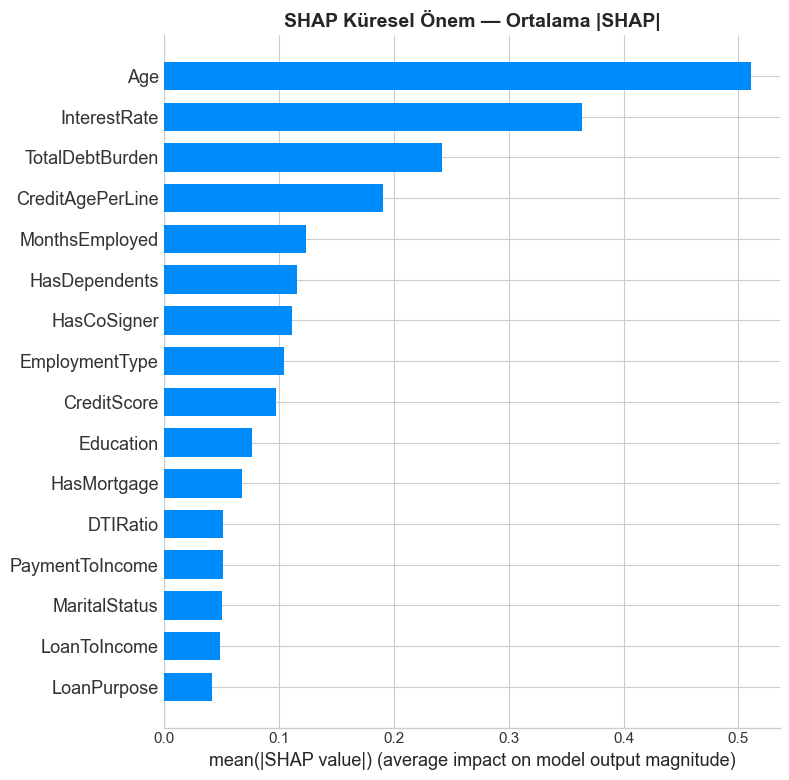

In [18]:
# SHAP Çubuk — ortalama mutlak SHAP değerleri ile küresel önem sıralaması
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values,
    X_shap,
    plot_type   = "bar",
    max_display = 16,
    show        = False,
)
plt.title("SHAP Küresel Önem — Ortalama |SHAP|", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "xgb_11_shap_importance_bar.png", dpi=150, bbox_inches="tight")
print("Kaydedildi: xgb_11_shap_importance_bar.png")
plt.show()

Kaydedildi: xgb_12_shap_waterfall.png


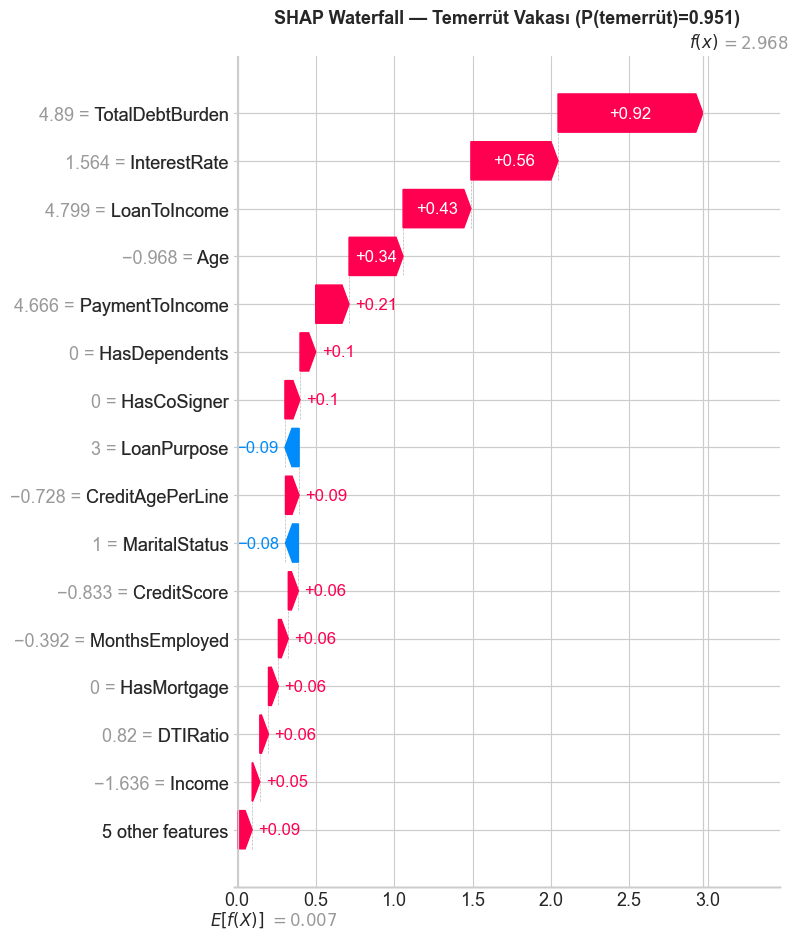

In [19]:
# SHAP Waterfall — tekil bir temerrüt vakasının tahmini adım adım açıklanır
# Modelin "neden temerrüt dedi?" sorusunu yanıtlar

# Yüksek riskli (yüksek temerrüt olasılıklı) bir temerrüt vakasını seç
y_prob_shap = final_model.predict_proba(X_shap)[:, 1]
default_mask = (y_shap == 1).values

# Temerrüt vakaları arasından en yüksek tahmin olasılıklı olanı seç
if default_mask.sum() > 0:
    candidate_probs = np.where(default_mask, y_prob_shap, -1)
    explain_idx = int(np.argmax(candidate_probs))
else:
    explain_idx = 0

# Yeni SHAP API: Explanation nesnesi
explanation = shap.Explanation(
    values        = shap_values[explain_idx],
    base_values   = explainer.expected_value,
    data          = X_shap.iloc[explain_idx].values,
    feature_names = list(X_train.columns),
)

plt.figure(figsize=(12, 7))
shap.waterfall_plot(explanation, max_display=16, show=False)
plt.title(
    f"SHAP Waterfall — Temerrüt Vakası (P(temerrüt)={y_prob_shap[explain_idx]:.3f})",
    fontsize=13, fontweight="bold",
)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "xgb_12_shap_waterfall.png", dpi=150, bbox_inches="tight")
print("Kaydedildi: xgb_12_shap_waterfall.png")
plt.show()

Kaydedildi: xgb_13_shap_dependence.png


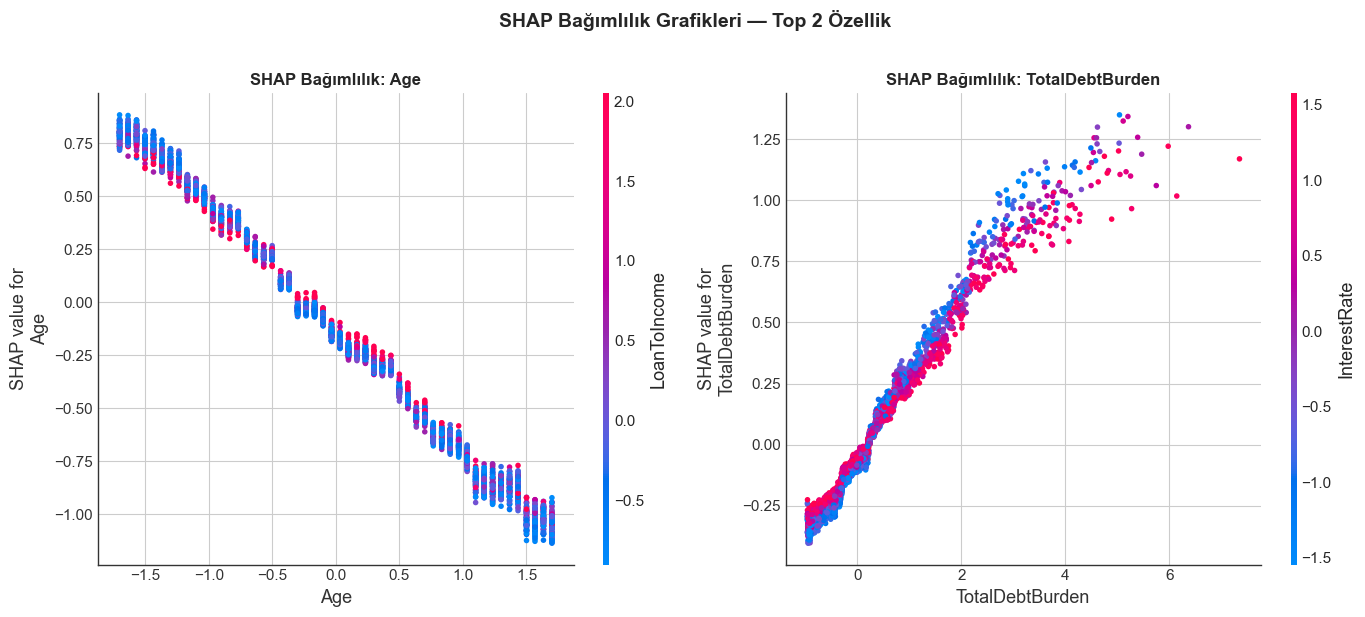

In [20]:
# SHAP Bağımlılık Grafikleri — en önemli 2 özellik için
# Bir özelliğin SHAP değerinin, değeri arttıkça nasıl değiştiğini gösterir
# Renk: en güçlü etkileşim içindeki özellik (otomatik seçilir)

top_2_features = importance_df["feature"].head(2).tolist()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, feature in zip(axes, top_2_features):
    shap.dependence_plot(
        feature,
        shap_values,
        X_shap,
        ax                = ax,
        show              = False,
        interaction_index = "auto",  # En güçlü etkileşim özelliğini otomatik belirle
    )
    ax.set_title(f"SHAP Bağımlılık: {feature}", fontsize=12, fontweight="bold")

fig.suptitle("SHAP Bağımlılık Grafikleri — Top 2 Özellik", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "xgb_13_shap_dependence.png", dpi=150, bbox_inches="tight")
print("Kaydedildi: xgb_13_shap_dependence.png")
plt.show()

## İyileştirme: SMOTE Dengeli Örnekleme

**Sorun:** Veri seti 7.6:1 dengesiz — model ödeme yapacak kişileri iyice öğrendi 
ama temerrüt vakalarını yeterince öğrenemedi → Precision çok düşük (0.23).

**Çözüm:** SMOTE (Synthetic Minority Oversampling Technique) — gerçek temerrüt 
vakalarının özelliklerini karıştırarak **yapay azınlık örnekleri** üretir. 
Model artık daha dengeli bir veri setinde eğitilir.

> **Not:** SMOTE yalnızca eğitim setine uygulanır. Test seti hiç dokunulmaz.

In [21]:
from imblearn.over_sampling import SMOTE
import time
import pandas as pd

# sampling_strategy=0.5: azınlık:çoğunluk = 1:2 oranına getir
# Tam denge (1:1) yerine 1:2 tercih edilir — aşırı örnekleme aşırı uyumu artırır
smote = SMOTE(
    sampling_strategy = 0.5,
    random_state = SEED,
    k_neighbors       = 5,  # Her azınlık örneği için 5 komşu kullan
)

print("SMOTE uygulanıyor (sadece eğitim setine)...")
t0 = time.time()
X_fit_smote, y_fit_smote = smote.fit_resample(X_fit, y_fit)
print(f"Tamamlandı: {time.time() - t0:.1f} saniye")

# Önce / sonra karşılaştırması
before_counts = pd.Series(y_fit).value_counts()
after_counts  = pd.Series(y_fit_smote).value_counts()

# Syntax hatası veren satır \n kullanılarak düzeltildi
print(f"\n{'Durum':<15} {'Ödendi':>10} {'Temerrüt':>10} {'Toplam':>10} {'Oran':>8}")
print("-" * 57)
print(f"{'SMOTE Öncesi':<15} {before_counts[0]:>10,} {before_counts[1]:>10,} "
      f"{len(y_fit):>10,} {before_counts[0]/before_counts[1]:>7.1f}:1")
print(f"{'SMOTE Sonrası':<15} {after_counts[0]:>10,} {after_counts[1]:>10,} "
      f"{len(y_fit_smote):>10,} {after_counts[0]/after_counts[1]:>7.1f}:1")

SMOTE uygulanıyor (sadece eğitim setine)...


  File "c:\Users\nesli\Desktop\LoanGuard\.venv\lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
  File "C:\Users\nesli\AppData\Local\Programs\Python\Python310\lib\subprocess.py", line 503, in run
    with Popen(*popenargs, **kwargs) as process:
  File "C:\Users\nesli\AppData\Local\Programs\Python\Python310\lib\subprocess.py", line 971, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\nesli\AppData\Local\Programs\Python\Python310\lib\subprocess.py", line 1456, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,


Tamamlandı: 0.5 saniye

Durum               Ödendi   Temerrüt     Toplam     Oran
---------------------------------------------------------
SMOTE Öncesi       153,471     20,164    173,635     7.6:1
SMOTE Sonrası      153,471     76,735    230,206     2.0:1


In [22]:
# SMOTE verisiyle model eğit — scale_pos_weight artık 1 çünkü veri zaten dengelendi
smote_params = {
    **random_search.best_params_,
    "scale_pos_weight"    : 1,      # SMOTE dengesizliği telafi etti
    "eval_metric"         : "auc",
    "tree_method"         : "hist",
    "random_state"        : SEED,
    "n_jobs"              : -1,
    "early_stopping_rounds": 30,
}

smote_model = XGBClassifier(**smote_params)

print("SMOTE modeli eğitiliyor...")
t0 = time.time()

smote_model.fit(
    X_fit_smote, y_fit_smote,
    # Geçerleme seti orijinal dağılımda — gerçek dünyayı simüle eder
    eval_set = [(X_val, y_val)],
    verbose  = 50,
)

print(f"Eğitim süresi   : {time.time() - t0:.1f} saniye")
print(f"En iyi iterasyon: {smote_model.best_iteration}")
print(f"En iyi val AUC  : {smote_model.best_score:.4f}")


SMOTE modeli eğitiliyor...
[0]	validation_0-auc:0.66527
[50]	validation_0-auc:0.72393
[100]	validation_0-auc:0.72884
[150]	validation_0-auc:0.73190
[200]	validation_0-auc:0.73303
[250]	validation_0-auc:0.73383
[300]	validation_0-auc:0.73512
[350]	validation_0-auc:0.73565
[399]	validation_0-auc:0.73597
Eğitim süresi   : 4.3 saniye
En iyi iterasyon: 376
En iyi val AUC  : 0.7360


In [23]:
# SMOTE modelini test seti üzerinde değerlendir
y_prob_smote = smote_model.predict_proba(X_test)[:, 1]

# Optimal eşiği bul
print("SMOTE MODEL — OPTIMAL EŞİK ANALİZİ")
print("-" * 40)
optimal_threshold_smote = find_optimal_threshold(y_test, y_prob_smote)
y_pred_smote_opt = (y_prob_smote >= optimal_threshold_smote).astype(int)

metrics_smote = evaluate_model(
    y_test, y_pred_smote_opt, y_prob_smote,
    threshold=optimal_threshold_smote,
    label="SMOTE Model — Optimal Eşik",
)


SMOTE MODEL — OPTIMAL EŞİK ANALİZİ
----------------------------------------
Optimal eşik       : 0.2234
Bu eşikteki Recall : 0.7004
Bu eşikteki Precis.: 0.2133

  SMOTE MODEL — OPTIMAL EŞIK  (Eşik = 0.2234)
  ROC-AUC                          0.7469
  PR-AUC                           0.3061
  F1 Skoru                         0.3270
  Hassasiyet (Precision)           0.2133
  Duyarlılık (Recall)              0.7004
  MCC                              0.2381
              precision    recall  f1-score   support

      Ödendi       0.94      0.66      0.78     45139
    Temerrüt       0.21      0.70      0.33      5931

    accuracy                           0.67     51070
   macro avg       0.58      0.68      0.55     51070
weighted avg       0.86      0.67      0.72     51070



In [24]:
# Üç modeli karşılaştır: Temel | Final | SMOTE
print("" + "="*68)
print("  MODEL KARŞILAŞTIRMASI (Test Seti — Optimal Eşik)")
print("="*68)
print(f"  {'Metrik':<22} {'Temel(0.5)':>12} {'Final(opt)':>12} {'SMOTE(opt)':>12}")
print("-"*68)

compare_keys = [
    ("roc_auc",   "ROC-AUC"),
    ("pr_auc",    "PR-AUC"),
    ("f1",        "F1"),
    ("precision", "Precision"),
    ("recall",    "Recall"),
    ("mcc",       "MCC"),
]

for key, label in compare_keys:
    b  = baseline_metrics.get(key, float('nan'))
    fo = metrics_opt.get(key, float('nan'))
    fs = metrics_smote.get(key, float('nan'))
    best = max(b, fo, fs)
    def fmt(v): return f"{v:.4f}" + (" *" if abs(v - best) < 1e-6 else "  ")
    print(f"  {label:<22} {fmt(b):>14} {fmt(fo):>14} {fmt(fs):>14}")

print("="*68)
print("  (* en iyi değer)")
print(f"  Kriter: Recall >= {MIN_RECALL:.2f} koşulunu sağlayanlar arasında max Precision")

# Recall hedefini karşılayan modeller arasından max Precision'u seç.
# Hiçbiri karşılamazsa en yüksek Recall'u al (fallback).
final_ok = metrics_opt["recall"] >= MIN_RECALL
smote_ok = metrics_smote["recall"] >= MIN_RECALL

if final_ok and smote_ok:
    if metrics_smote["precision"] > metrics_opt["precision"]:
        print(f"→ SMOTE modeli daha yüksek Precision ({metrics_smote['precision']:.4f}) — kaydedilecek.")
        best_model       = smote_model
        best_threshold   = optimal_threshold_smote
        best_metrics     = metrics_smote
        best_model_label = "smote"
    else:
        print(f"→ Final model daha yüksek Precision ({metrics_opt['precision']:.4f}) — kaydedilecek.")
        best_model       = final_model
        best_threshold   = optimal_threshold
        best_metrics     = metrics_opt
        best_model_label = "original"
elif final_ok:
    print(f"→ Yalnızca Final model Recall >= {MIN_RECALL:.2f} hedefini karşılıyor — kaydedilecek.")
    best_model       = final_model
    best_threshold   = optimal_threshold
    best_metrics     = metrics_opt
    best_model_label = "original"
elif smote_ok:
    print(f"→ Yalnızca SMOTE modeli Recall >= {MIN_RECALL:.2f} hedefini karşılıyor — kaydedilecek.")
    best_model       = smote_model
    best_threshold   = optimal_threshold_smote
    best_metrics     = metrics_smote
    best_model_label = "smote"
else:
    print(f"[UYARI] Hiçbir model Recall >= {MIN_RECALL:.2f} hedefini karşılamadı. En yüksek Recall'lu model seçildi.")
    if metrics_smote["recall"] > metrics_opt["recall"]:
        best_model       = smote_model
        best_threshold   = optimal_threshold_smote
        best_metrics     = metrics_smote
        best_model_label = "smote"
    else:
        best_model       = final_model
        best_threshold   = optimal_threshold
        best_metrics     = metrics_opt
        best_model_label = "original"

  MODEL KARŞILAŞTIRMASI (Test Seti — Optimal Eşik)
  Metrik                   Temel(0.5)   Final(opt)   SMOTE(opt)
--------------------------------------------------------------------
  ROC-AUC                      0.7549         0.7595 *       0.7469  
  PR-AUC                       0.3278         0.3336 *       0.3061  
  F1                           0.3427 *       0.3393         0.3270  
  Precision                    0.2299 *       0.2234         0.2133  
  Recall                       0.6727         0.7048 *       0.7004  
  MCC                          0.2548 *       0.2547         0.2381  
  (* en iyi değer)
  Kriter: Recall >= 0.70 koşulunu sağlayanlar arasında max Precision
→ Final model daha yüksek Precision (0.2234) — kaydedilecek.


Kaydedildi: xgb_14_roc_smote_comparison.png


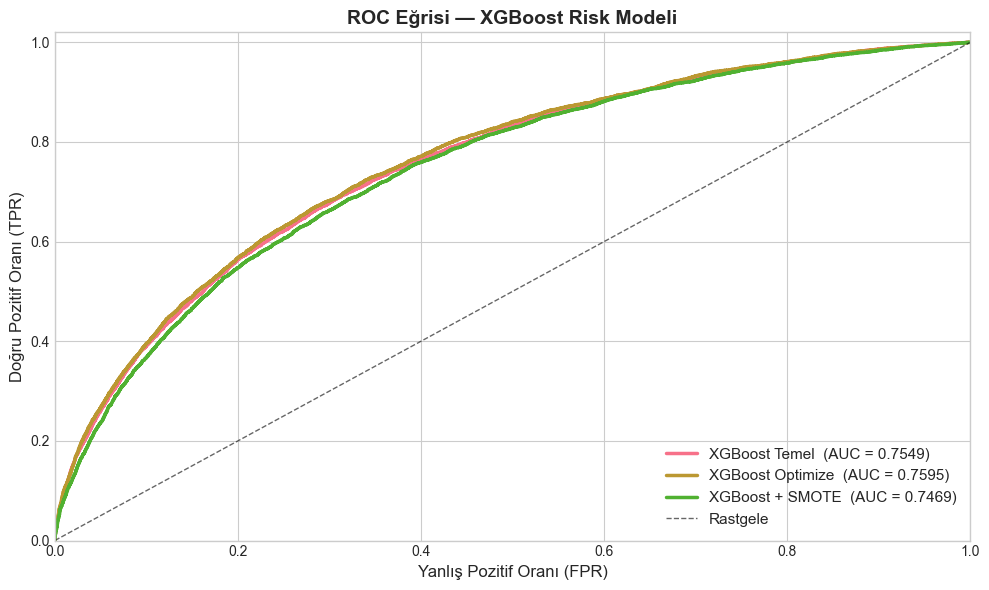

Kaydedildi: xgb_15_pr_smote_comparison.png


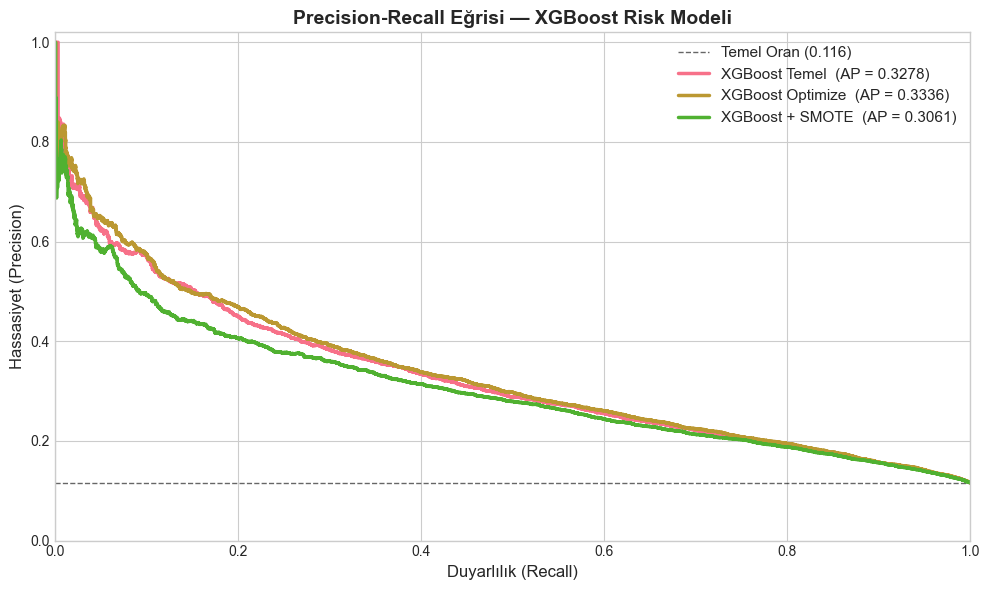

Kaydedildi: xgb_16_cm_smote.png


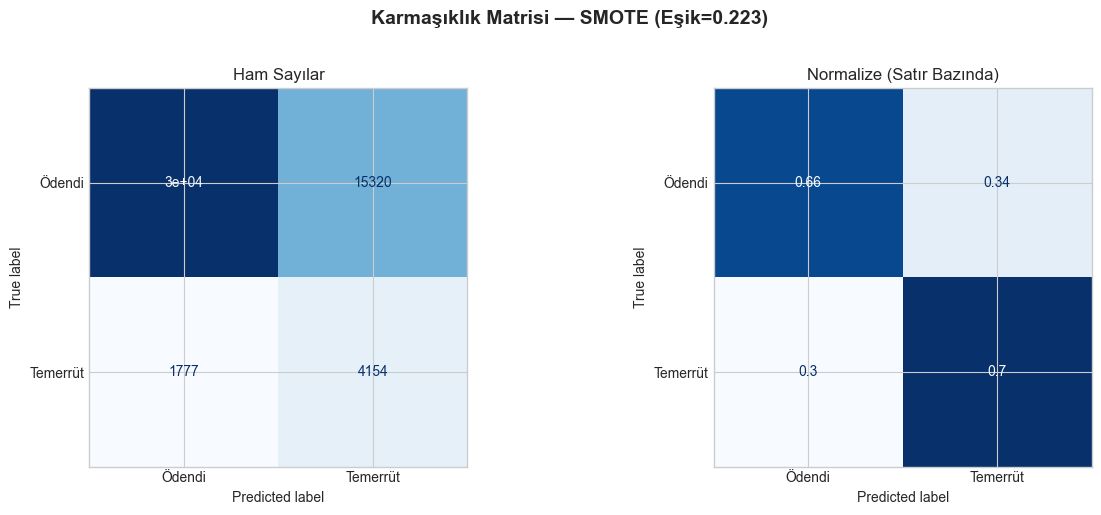

In [25]:
# ROC ve PR karşılaştırma grafiklerini güncelle — SMOTE dahil
all_models = {
    "XGBoost Temel"   : y_prob_baseline,
    "XGBoost Optimize": y_prob_final,
    "XGBoost + SMOTE" : y_prob_smote,
}

plot_roc_curve(y_test, all_models,
               save_path=FIGURES_DIR / "xgb_14_roc_smote_comparison.png")
plot_pr_curve(y_test, all_models,
              save_path=FIGURES_DIR / "xgb_15_pr_smote_comparison.png")
plot_confusion_matrix(
    y_test, y_pred_smote_opt,
    title=f"Karmaşıklık Matrisi — SMOTE (Eşik={optimal_threshold_smote:.3f})",
    save_path=FIGURES_DIR / "xgb_16_cm_smote.png",
)


## 8. Model & Metrik Kayıt

In [26]:
def save_model_artifacts(
    model: XGBClassifier,
    model_dir: Path,
    best_params: dict,
    optimal_threshold: float,
    feature_names: list,
    min_recall: float = MIN_RECALL,
) -> None:
    """
    Eğitilmiş modeli ve çıkarım için gereken meta verileri diske kaydeder.
    Kaydedilen dosyalar pipeline aşaması 2'de kullanılacaktır.

    Args:
        model             : Eğitilmiş XGBClassifier
        model_dir         : Kayıt dizini
        best_params       : RandomizedSearchCV'nin seçtiği en iyi parametreler
        optimal_threshold : Recall >= min_recall koşulunda Precision'ı maksimize eden karar eşiği
        feature_names     : Modelin beklediği özellik adları (sıralı)
        min_recall        : Threshold optimizasyonunda kullanılan minimum Recall kısıtı
    """
    model_path = model_dir / "xgboost_risk_model.joblib"
    joblib.dump(model, model_path, compress=3)
    print(f"Model kaydedildi : {model_path}")

    def to_python(v):
        if isinstance(v, np.floating): return float(v)
        if isinstance(v, np.integer):  return int(v)
        return v

    metadata = {
        "model_version"      : "1.0.0",
        "trained_at"         : datetime.now().isoformat(),
        "best_iteration"     : int(model.best_iteration),
        "optimal_threshold"  : float(optimal_threshold),
        "threshold_criterion": f"max_precision_at_recall_gte_{min_recall}",
        "min_recall_target"  : float(min_recall),
        "scale_pos_weight"   : float(xgb_cfg["scale_pos_weight"]),
        "feature_names"      : feature_names,
        "n_features"         : len(feature_names),
        "train_samples"      : len(X_fit),
        "best_params"        : {k: to_python(v) for k, v in best_params.items()},
    }

    meta_path = model_dir / "xgboost_metadata.json"
    with open(meta_path, "w", encoding="utf-8") as f:
        json.dump(metadata, f, indent=4, ensure_ascii=False)
    print(f"Meta veri kaydedildi: {meta_path}")


save_model_artifacts(
    model             = best_model,
    model_dir         = MODELS_DIR,
    best_params       = random_search.best_params_,
    optimal_threshold = best_threshold,
    feature_names     = list(X_train.columns),
    min_recall        = MIN_RECALL,
)

Model kaydedildi : C:\Users\nesli\Desktop\LoanGuard\models\xgboost_risk_model.joblib
Meta veri kaydedildi: C:\Users\nesli\Desktop\LoanGuard\models\xgboost_metadata.json


In [27]:
def save_metrics(metrics_dir: Path, filename: str, **metric_groups) -> None:
    """
    Tüm model metriklerini JSON dosyasına kaydeder.
    Ekip üyeleri ve raporlama için standardize edilmiş format.

    Args:
        metrics_dir   : Kayıt dizini
        filename      : JSON dosya adı
        **metric_groups : {grup_adı: metrik_sözlüğü} anahtar-kelime argümanları
    """
    def to_python(v):
        if isinstance(v, float):       return round(v, 6)
        if isinstance(v, np.floating): return round(float(v), 6)
        if isinstance(v, np.integer):  return int(v)
        return v

    output = {
        "generated_at": datetime.now().isoformat(),
    }
    for group_name, group_metrics in metric_groups.items():
        output[group_name] = {k: to_python(v) for k, v in group_metrics.items()}

    path = metrics_dir / filename
    with open(path, "w", encoding="utf-8") as f:
        json.dump(output, f, indent=4, ensure_ascii=False)
    print(f"Metrikler kaydedildi: {path}")


save_metrics(
    metrics_dir = METRICS_DIR,
    filename    = "xgboost_metrics.json",
    baseline    = baseline_metrics,
    final_05    = metrics_05,
    final_opt   = metrics_opt,
    search      = {
        "best_cv_auc"    : random_search.best_score_,
        "n_iter"         : 20,
        "cv_folds"       : 3,
        "optimal_threshold": optimal_threshold,
    },
)

Metrikler kaydedildi: C:\Users\nesli\Desktop\LoanGuard\reports\metrics\xgboost_metrics.json


## 9. Özet Rapor

In [28]:
SEP = "=" * 62
print(SEP)
print("  XGBoost RİSK MODELİ — ÖZET RAPOR")
print(SEP)

print("\nVERİ")
print(f"  Eğitim (fit)  : {len(X_fit):>7,} örnek")
print(f"  Test          : {len(X_test):>7,} örnek")
print(f"  Özellik sayısı: {X_train.shape[1]}")
print(f"  Sınıf dengesi : 7.6:1  →  scale_pos_weight={xgb_cfg['scale_pos_weight']}")

print("\nHİPERPARAMETRE OPTİMİZASYONU")
print(f"  Yöntem         : RandomizedSearchCV (20 iter × 3 kat)")
print(f"  Hedef metrik   : ROC-AUC")
print(f"  En iyi CV AUC  : {random_search.best_score_:.4f}")
print(f"  En iyi iter.   : {final_model.best_iteration}")

print("\nEŞİK OPTİMİZASYONU")
print(f"  Kriter         : max Precision @ Recall >= {MIN_RECALL:.2f}")
print(f"  Optimal Eşik   : {best_threshold:.4f}")
print(f"  Seçilen Model  : {best_model_label}")

print("\nPERFORANS (Test Seti — Seçilen Model)")
print(f"  {'Metrik':<30} {'Temel(0.5)':>10}  {'Seçilen(opt)':>12}")
print(f"  {'-'*56}")
for key, label in [("roc_auc","ROC-AUC"),("pr_auc","PR-AUC"),("f1","F1"),("recall","Recall"),("precision","Precision"),("mcc","MCC")]:
    b  = baseline_metrics.get(key, float('nan'))
    bo = best_metrics.get(key, float('nan'))
    print(f"  {label:<30} {b:>10.4f}  {bo:>12.4f}")

print("\nKAYDEDİLEN DOSYALAR")
for p in [
    MODELS_DIR / "xgboost_risk_model.joblib",
    MODELS_DIR / "xgboost_metadata.json",
    METRICS_DIR / "xgboost_metrics.json",
]:
    status = "[OK]" if p.exists() else "[EKSIK]"
    print(f"  {status}  {p.relative_to(PROJECT_ROOT)}")

shap_figs = sorted(FIGURES_DIR.glob("xgb_*.png"))
print(f"\n  Grafik sayısı  : {len(shap_figs)} dosya  →  reports/figures/xgb_*.png")

print("\nSONRAKİ ADIM")
print("  02b_feature_engineering.ipynb → Finansal rasyolar üretimi")
print("  Ardından 03_xgboost_risk_model.ipynb yeniden eğitim")
print(SEP)

  XGBoost RİSK MODELİ — ÖZET RAPOR

VERİ
  Eğitim (fit)  : 173,635 örnek
  Test          :  51,070 örnek
  Özellik sayısı: 20
  Sınıf dengesi : 7.6:1  →  scale_pos_weight=7.6

HİPERPARAMETRE OPTİMİZASYONU
  Yöntem         : RandomizedSearchCV (20 iter × 3 kat)
  Hedef metrik   : ROC-AUC
  En iyi CV AUC  : 0.7528
  En iyi iter.   : 397

EŞİK OPTİMİZASYONU
  Kriter         : max Precision @ Recall >= 0.70
  Optimal Eşik   : 0.4885
  Seçilen Model  : original

PERFORANS (Test Seti — Seçilen Model)
  Metrik                         Temel(0.5)  Seçilen(opt)
  --------------------------------------------------------
  ROC-AUC                            0.7549        0.7595
  PR-AUC                             0.3278        0.3336
  F1                                 0.3427        0.3393
  Recall                             0.6727        0.7048
  Precision                          0.2299        0.2234
  MCC                                0.2548        0.2547

KAYDEDİLEN DOSYALAR
  [OK]  models